# Heavy traffic: near saturation, the queue forgets the distribution

To predict latency under heavy load, do you need to know the full shape of your service-time
distribution? A remarkable result says **no**: as utilization `ρ → 1`, the waiting-time distribution
of an M/G/1 queue converges to an **exponential**, whatever the service distribution was. Only its
**first two moments** survive; every other detail washes out.

A clean fingerprint of "exponential" is a coefficient of variation equal to 1
(`C_W = std(W)/mean(W) = 1`). We watch `C_W` for three very different services collapse to 1 as the
system saturates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.random.distributions import GammaDistribution
from most_queue.sim.base import QsSim

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})

def wait_cv(kind, cv_service, rho, njobs=300_000, seed=1):
    s = QsSim(1, verbose=False, seed=seed)
    s.set_sources(rho, "M")            # Poisson arrivals; mean service = 1 so rho = arrival rate
    if kind == "D":
        s.set_servers(1.0, "D")
    elif kind == "M":
        s.set_servers(1.0, "M")
    else:
        s.set_servers(GammaDistribution.get_params_by_mean_and_cv(1.0, cv_service), "Gamma")
    w = s.run(njobs).w                 # raw moments of waiting time
    if w[0] <= 0:
        return np.nan
    return np.sqrt(max(w[1] - w[0]**2, 0.0)) / w[0]


## Three very different services, one destination

- **Deterministic** service (C²=0) — the most regular possible.
- **Exponential** service (C²=1).
- **Hyper/heavy-tailed** service (C²≈6) — very irregular.

We track the waiting-time CV as load rises toward 1.

Start simulation

Simulation is finished

Start simulation

Simulation is finished

Start simulation

...

Simulation is finished

Start simulation

Simulation is finished

Start simulation

Simulation is finished

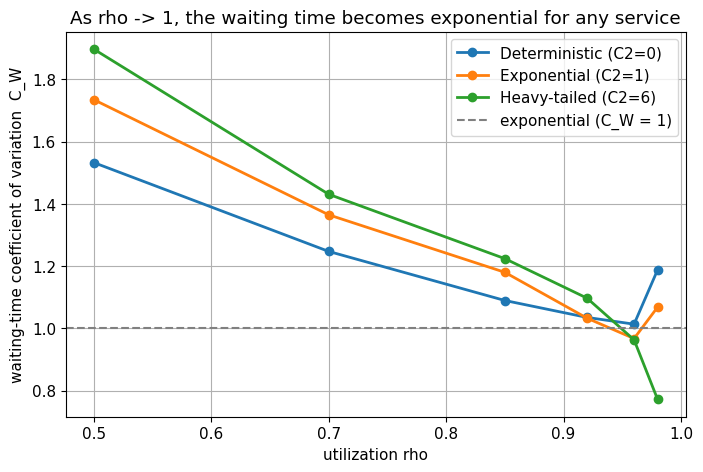

waiting-time CV (-> 1 means exponential):

Start simulation

Simulation is finished

Start simulation

Simulation is finished

...

Start simulation

Simulation is finished

Start simulation

Simulation is finished

  Heavy-tailed (C2=6)   : rho=0.5 -> 1.90,  rho=0.96 -> 0.96

In [2]:
rhos = [0.5, 0.7, 0.85, 0.92, 0.96, 0.98]
services = [("Deterministic (C2=0)", "D", 0.0),
            ("Exponential (C2=1)", "M", 1.0),
            ("Heavy-tailed (C2=6)", "Gamma", np.sqrt(6.0))]

fig, ax = plt.subplots()
for name, kind, cvs in services:
    ys = [wait_cv(kind, cvs, r) for r in rhos]
    ax.plot(rhos, ys, "o-", lw=2, label=name)
ax.axhline(1.0, ls="--", color="gray", label="exponential (C_W = 1)")
ax.set_xlabel("utilization rho")
ax.set_ylabel("waiting-time coefficient of variation  C_W")
ax.set_title("As rho -> 1, the waiting time becomes exponential for any service")
ax.legend()
plt.show()

print("waiting-time CV (-> 1 means exponential):")
for name, kind, cvs in services:
    print(f"  {name:22}: rho=0.5 -> {wait_cv(kind,cvs,0.5):.2f},  rho=0.96 -> {wait_cv(kind,cvs,0.96):.2f}")


**The insight.** At light load the three services behave very differently (their waiting-time
CVs are far apart). As the system approaches saturation, all three converge to `C_W = 1` — the
signature of an exponential distribution. The heavy-traffic limit **erases the shape** of the
service distribution; the queue's behaviour is governed only by the load and the first two moments
(this is the diffusion / reflected-Brownian-motion approximation).

## Why this is useful

- **Simple models are enough where it hurts.** Systems are most painful near saturation — and that's
  exactly where an exponential (two-moment) approximation of the waiting time becomes accurate. You
  don't need to fit the full distribution to reason about tail latency under stress.
- **Two moments summarize the tail.** Mean and variance of service (i.e. the mean and `C²`) are the
  only inputs that matter in heavy traffic — consistent with the Pollaczek–Khinchine mean
  (see [variability_matters.ipynb](variability_matters.ipynb)).
- It also explains why so many overloaded systems show roughly exponential latency tails regardless
  of their internals.

## Takeaways

- **Heavy-traffic limit**: as `ρ → 1`, M/G/1 waiting time → exponential, for *any* service
  distribution. `C_W → 1`.
- Near saturation only the first two moments matter — a two-parameter model captures the tail.